# Multivariate Empirical Mode Decomposition (MEMD)

**MEMD** (Rehman & Mandic, 2010) extends classical Huang EMD from a single
channel to an *n*-variate series. Local extrema are not well-defined in
\(\mathbb{R}^n\) (the field is not ordered), so MEMD never looks for maxima of
the vector signal itself. Instead it:

1. samples a set of **direction vectors** on the unit \((n-1)\)-sphere;
2. **projects** the multivariate record onto each direction, obtaining a
   real-valued scalar series;
3. finds 1-D extrema of every projection and interpolates those time instants
   **component-wise** to build *n*-dimensional envelopes;
4. averages the envelopes to estimate the **local mean**, then sifts as in EMD.

All channels therefore share the same number of IMFs and the same time scales
(**mode alignment**). That is the property that makes MEMD useful for
multichannel fusion; independent per-channel EMD does **not** keep IMF indices
aligned.

The PySDKit class `MEMD` is a port of the authors' MATLAB toolbox (`memd.m`),
including Hammersley directions, the Rilling `"stop"` criterion and the Huang
`"fix_h"` criterion.

| | **EMD** | **MEMD** (this notebook) | **MVMD** |
|---|---|---|---|
| Input | `(T,)` | `(C, T)`, `3 ≤ C ≤ 16` | `(C, T)` |
| Output | `(K, T)` | `(K, T, C)` (last slice = residue) | `(K, T, C)` |
| Local mean | spline envelopes of extrema | mean of projected multivariate envelopes | variational |
| Directions | — | Hammersley on the \((n-1)\)-sphere | — |

**References**

> N. Rehman and D. P. Mandic.
> *Multivariate empirical mode decomposition.*
> Proc. R. Soc. A **466**, 1291–1302 (2010).
> https://doi.org/10.1098/rspa.2009.0502

MATLAB toolbox (Rehman & Mandic): `repo/memd/memd.m`.
Demo records: `syn_hex_inp.mat`, `syn_12channel_inp.mat`,
`syn_16channel_inp.mat`, `taichi_hex_inp.mat`.


## 1. Imports


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from pysdkit import MEMD
from pysdkit._emd.memd import spherical_coordinate_directions
from pysdkit.data import (
    load_memd_syn_hex,
    load_memd_syn_12channel,
    load_memd_syn_16channel,
    load_memd_taichi_hex,
)

print("pysdkit from:", Path(__import__("pysdkit").__file__).resolve())
print(MEMD())

pysdkit from: C:\Users\whenx\Desktop\PySDKit\pysdkit\__init__.py
Multivariate Empirical Mode Decomposition (MEMD)


## 2. Direction vectors on the 2-sphere (paper Figure 1)

The local-mean step is a discrete approximation of an integral over all
envelopes on the sphere. Accuracy is therefore limited by **how uniformly**
the \(K\) directions cover \(S^{n-1}\).

Two constructions appear in the paper:

- **Uniform angular sampling** (eq. 3.2). Equal steps in the hyperspherical
  angles \((\theta_1,\theta_2,\ldots)\) are easy to write down, but they are
  *not* uniform with respect to surface measure. On the ordinary 2-sphere the
  meridians pinch together at the poles, so projections are oversampled there
  and undersampled at the equator.
- **Hammersley / Halton low-discrepancy sequence.** Quasi-Monte Carlo points
  have a smaller discrepancy than a latitude–longitude grid (and than i.i.d.
  Monte Carlo). Mapping them onto the sphere gives the directions used by
  `memd.m` and by PySDKit.

Rule of thumb from the MATLAB help: take **at least** \(K \approx 2C\)
directions, and typically much more (default \(K=64\)). The implementation
does **not** silently replace `n_dir` by `2 * n_channels`.


Hammersley directions: (64, 3) unit-norm max error 2.220446049250313e-16
Angular grid directions: (128, 3)


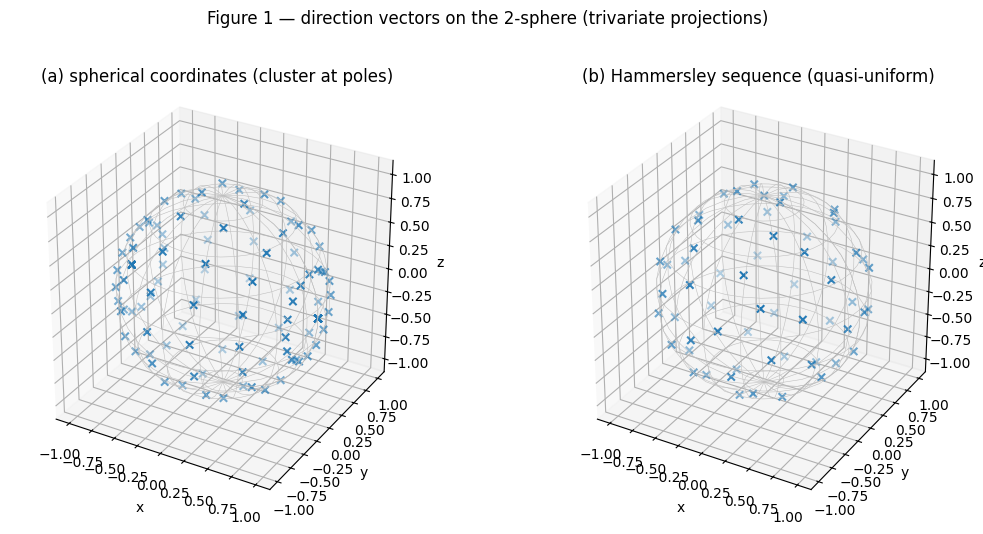

In [2]:
n_dir = 64
memd_dirs = MEMD(n_dir=n_dir)
hamm_pts = memd_dirs.direction_vectors(3)
grid_pts = spherical_coordinate_directions(n_phi=16, n_theta=8)

print(
    "Hammersley directions:",
    hamm_pts.shape,
    "unit-norm max error",
    np.max(np.abs(np.linalg.norm(hamm_pts, axis=1) - 1.0)),
)
print("Angular grid directions:", grid_pts.shape)

fig = plt.figure(figsize=(11, 5))
ax0 = fig.add_subplot(1, 2, 1, projection="3d")
ax1 = fig.add_subplot(1, 2, 2, projection="3d")


def _draw_sphere(ax, pts, title):
    u = np.linspace(0.0, 2.0 * np.pi, 36)
    v = np.linspace(0.0, np.pi, 18)
    xs = np.outer(np.cos(u), np.sin(v)).T
    ys = np.outer(np.sin(u), np.sin(v)).T
    zs = np.outer(np.ones_like(u), np.cos(v)).T
    ax.plot_wireframe(xs, ys, zs, color="0.75", linewidth=0.4, rstride=2, cstride=2)
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c="C0", marker="x", s=28)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_box_aspect((1, 1, 1))


_draw_sphere(ax0, grid_pts, "(a) spherical coordinates (cluster at poles)")
_draw_sphere(ax1, hamm_pts, "(b) Hammersley sequence (quasi-uniform)")
fig.suptitle(
    "Figure 1 — direction vectors on the 2-sphere (trivariate projections)", y=1.02
)
plt.tight_layout()
plt.show()

Panel (a) reproduces the latitude–longitude grid of the paper: points pile up
at the poles. Panel (b) is the Hammersley set actually used inside `MEMD`.
Because envelope averaging is a numerical integral, the uniform covering in
(b) gives a less biased local mean, and therefore more stable multivariate
IMFs.

For \(C=3\) the toolbox maps a 2-D Hammersley sample \((u,v)\) by
\(z = 2u-1\), \(\varphi = 2\pi v\),
\((x,y,z) = (\sqrt{1-z^2}\cos\varphi,\;\sqrt{1-z^2}\sin\varphi,\; z)\).
For \(C>3\) the same sequence is lifted through the hyperspherical chart.


## 3. Algorithm (paper Algorithm 2)

Given \(\{v(t)\}_{t=1}^{T} \subset \mathbb{R}^n\) and directions
\(\{x^{\theta_k}\}_{k=1}^{K}\) on \(S^{n-1}\):

1. Project \(p^{\theta_k}(t) = \langle v(t), x^{\theta_k}\rangle\).
2. Locate extrema times \(\{t_i^{\theta_k}\}\) of each scalar projection.
3. Interpolate the *vector* samples \(v(t_i^{\theta_k})\) with cubic splines
   to obtain envelope curves \(e^{\theta_k}(t)\).
4. Average \(m(t) = \frac{1}{K}\sum_k e^{\theta_k}(t)\).
5. Extract the detail \(d(t) = v(t) - m(t)\). If \(d\) satisfies the
   multivariate IMF stoppage criterion, store it and repeat on the residue;
   otherwise keep sifting \(d\).

PySDKit layout: input `(C, T)`, output `(K, T, C)` with the last plane equal
to the residue, so `imfs.sum(axis=0).T` reconstructs the input.


In [3]:
rng = np.random.default_rng(0)
n_samples = 400
fs = 200.0
t = np.arange(n_samples) / fs
# Shared 4 Hz tone on every channel + channel-specific higher oscillations
ch0 = np.cos(2 * np.pi * 4 * t) + 0.6 * np.cos(2 * np.pi * 18 * t)
ch1 = np.cos(2 * np.pi * 4 * t) + 0.5 * np.sin(2 * np.pi * 11 * t)
ch2 = 0.4 * np.cos(2 * np.pi * 4 * t) + 0.8 * np.cos(2 * np.pi * 18 * t)
signal = np.vstack([ch0, ch1, ch2])

memd = MEMD(n_dir=32, max_iter=200)
imfs = memd.fit_transform(signal)
print("input", signal.shape, "IMFs", imfs.shape)
print("reconstruction max |error|", np.max(np.abs(imfs.sum(axis=0).T - signal)))
print(memd)

input (3, 400) IMFs (4, 400, 3)
reconstruction max |error| 2.220446049250313e-16
Multivariate Empirical Mode Decomposition (MEMD)


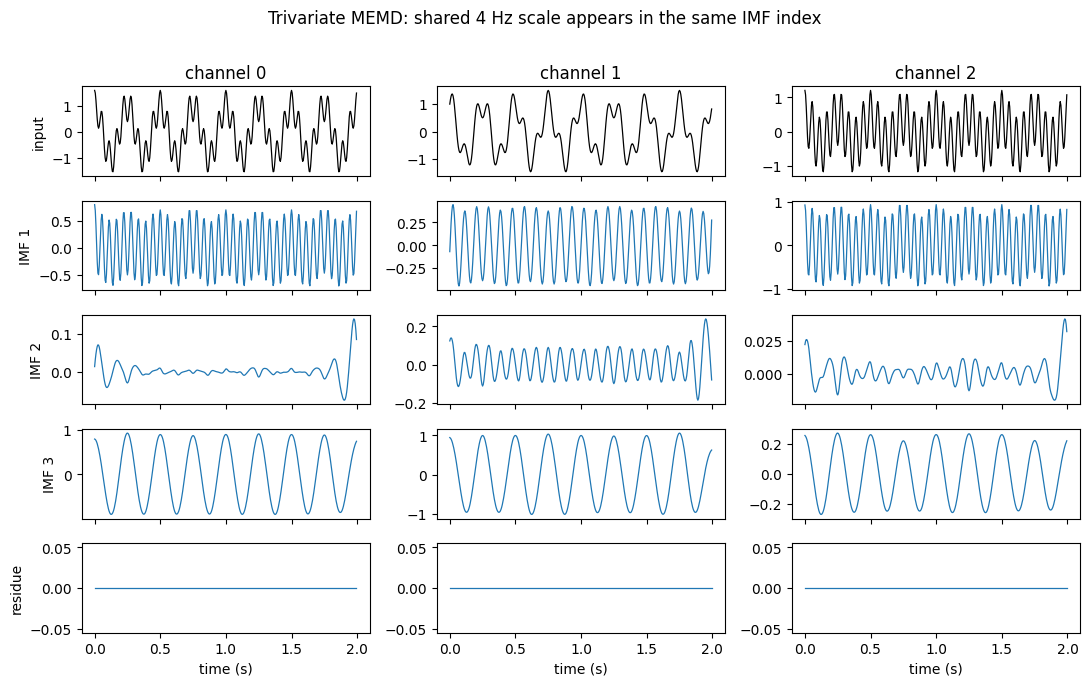

In [4]:
n_imfs = imfs.shape[0]
fig, axes = plt.subplots(n_imfs + 1, 3, figsize=(11, 1.35 * (n_imfs + 1)), sharex=True)
labels = ["channel 0", "channel 1", "channel 2"]
for c in range(3):
    axes[0, c].plot(t, signal[c], color="k", lw=0.9)
    axes[0, c].set_title(labels[c])
    if c == 0:
        axes[0, c].set_ylabel("input")
    for k in range(n_imfs):
        axes[k + 1, c].plot(t, imfs[k, :, c], lw=0.9)
        if c == 0:
            ylab = "residue" if k == n_imfs - 1 else f"IMF {k + 1}"
            axes[k + 1, c].set_ylabel(ylab)
        if k == n_imfs - 1:
            axes[k + 1, c].set_xlabel("time (s)")
fig.suptitle("Trivariate MEMD: shared 4 Hz scale appears in the same IMF index", y=1.01)
plt.tight_layout()
plt.show()

The 4 Hz component is present on every channel and therefore occupies the
**same IMF row** across columns. That is mode alignment: a single multivariate
IMF carries one common oscillatory scale, not a jumble of per-channel EMD
orders.


## 4. Projecting a trivariate trajectory

Geometrically, each MEMD sifting step looks at the 3-D path
\(v(t)=(x(t),y(t),z(t))\) from many viewing directions. The plot below shows
a short rotating trajectory, a handful of Hammersley arrows, and the scalar
projection onto one of them (the series whose extrema define that envelope).


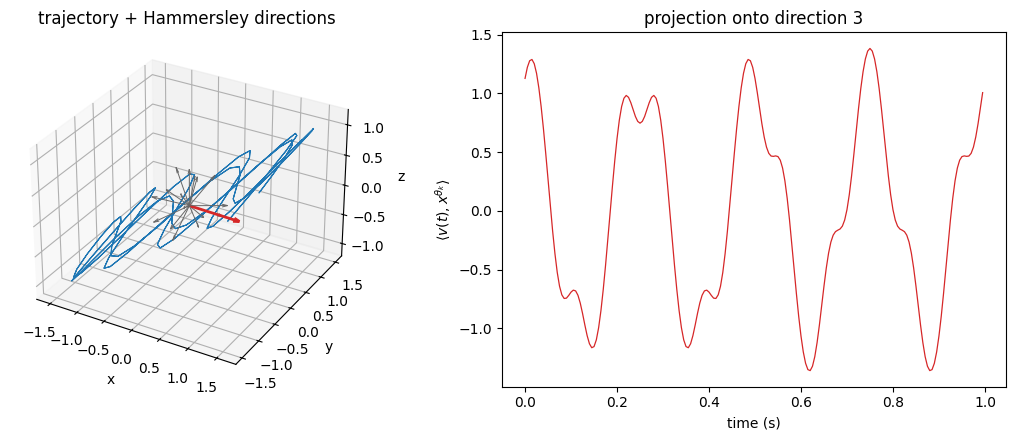

In [5]:
dirs = MEMD(n_dir=16).direction_vectors(3)
seg = signal[:, :200].T  # (T, 3)
k_show = 3
proj = seg @ dirs[k_show]

fig = plt.figure(figsize=(11, 4.5))
ax3 = fig.add_subplot(1, 2, 1, projection="3d")
ax3.plot(seg[:, 0], seg[:, 1], seg[:, 2], color="C0", lw=0.8)
origin = np.zeros(3)
for vec in dirs:
    ax3.quiver(*origin, *0.6 * vec, color="0.4", lw=0.7, arrow_length_ratio=0.15)
ax3.quiver(*origin, *0.9 * dirs[k_show], color="C3", lw=2.0, arrow_length_ratio=0.12)
ax3.set_title("trajectory + Hammersley directions")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("z")

axp = fig.add_subplot(1, 2, 2)
axp.plot(t[:200], proj, color="C3", lw=0.9)
axp.set_title(f"projection onto direction {k_show}")
axp.set_xlabel("time (s)")
axp.set_ylabel(r"$\langle v(t), x^{\theta_k}\rangle$")
plt.tight_layout()
plt.show()

## 5. MATLAB hexavariate synthetic (`syn_hex_inp.mat`)

The paper's Figure 3 uses a six-channel series in which four sinusoids are
combined so that **one tone is common to every variate** and the others are
shared by subsets of channels. The MATLAB session is

```matlab
load syn_hex_inp.mat          % variable s6, size 6 x 1001
imf = memd(s6, 256, 'stop', [0.05 0.5 0.05]);
```

PySDKit ships the same array as `load_memd_syn_hex()` with layout `(6, 1001)`.
We use \(K=64\) directions (the toolbox default; the paper used 512, which is
heavier but not required to see mode alignment).


In [6]:
hex_demo = load_memd_syn_hex()
hex_sig = hex_demo["signal"]
hex_t = hex_demo["t"]
print("hexavariate synthetic:", hex_sig.shape)

hex_memd = MEMD(n_dir=64, max_iter=200, stop_vec=[0.05, 0.5, 0.05])
hex_imfs = hex_memd.fit_transform(hex_sig)
print(
    "IMFs",
    hex_imfs.shape,
    "recon max |error|",
    np.max(np.abs(hex_imfs.sum(axis=0).T - hex_sig)),
)

hexavariate synthetic: (6, 1001)


IMFs (11, 1001, 6) recon max |error| 1.7763568394002505e-15


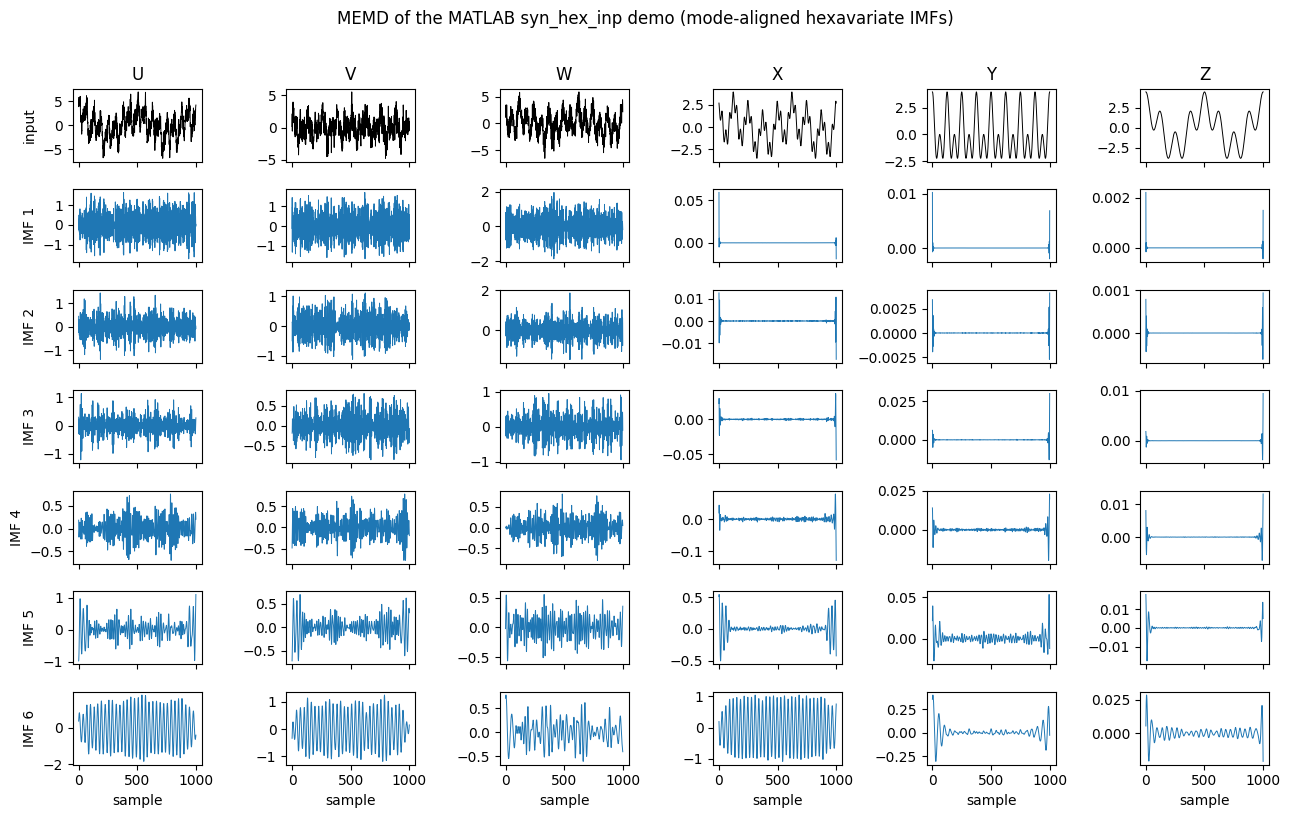

In [7]:
channel_names = list("UVWXYZ")
n_show = min(hex_imfs.shape[0], 6)
fig, axes = plt.subplots(n_show + 1, 6, figsize=(13, 1.15 * (n_show + 1)), sharex=True)
for c, name in enumerate(channel_names):
    axes[0, c].plot(hex_t, hex_sig[c], color="k", lw=0.7)
    axes[0, c].set_title(name)
    if c == 0:
        axes[0, c].set_ylabel("input")
    for k in range(n_show):
        axes[k + 1, c].plot(hex_t, hex_imfs[k, :, c], lw=0.7)
        if c == 0:
            ylab = (
                "residue"
                if k == hex_imfs.shape[0] - 1 or k == n_show - 1
                else f"IMF {k + 1}"
            )
            if k == n_show - 1 and hex_imfs.shape[0] > n_show:
                ylab = f"IMF {k + 1}"
            axes[k + 1, c].set_ylabel(ylab)
        if k == n_show - 1:
            axes[k + 1, c].set_xlabel("sample")
fig.suptitle(
    "MEMD of the MATLAB syn_hex_inp demo (mode-aligned hexavariate IMFs)", y=1.01
)
plt.tight_layout()
plt.show()

## 6. 12- and 16-channel MATLAB synthetics

`syn_12channel_inp.mat` (`s12`) mixes five tones plus noise on some channels;
`syn_16channel_inp.mat` (`s16`) mixes six tones. Both are length 1001. A
moderate \(K\) already shows joint scales; use `n_dir=64` (or 128) for a
closer match to the toolbox defaults.


12-channel (12, 1001) 16-channel (16, 1001)


12-channel IMFs (9, 1001, 12) recon 1.7763568394002505e-15
16-channel IMFs (9, 1001, 16) recon 2.6645352591003757e-15


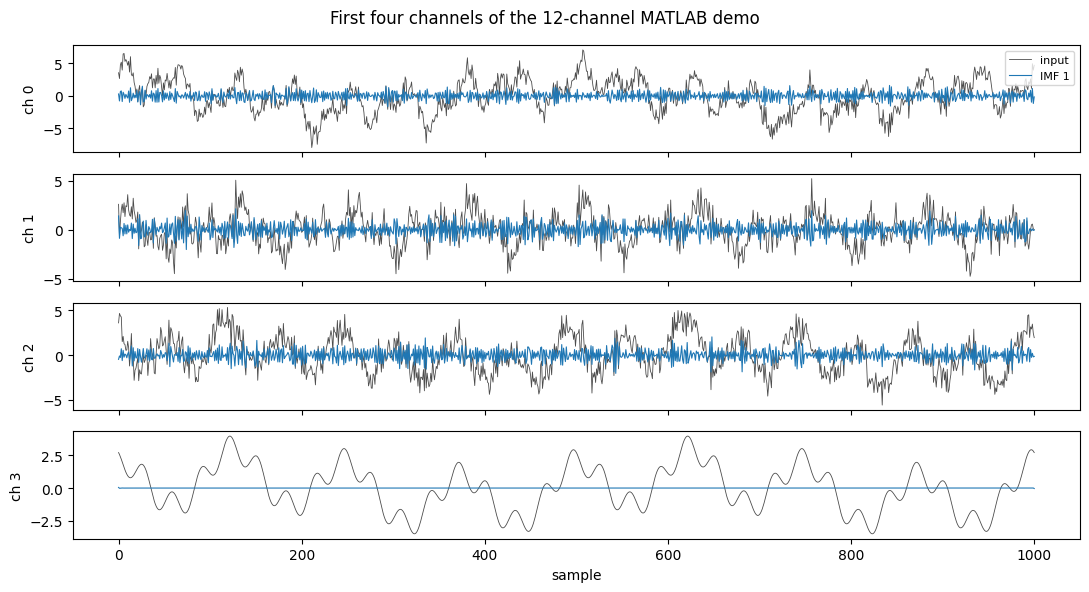

In [8]:
ch12 = load_memd_syn_12channel()["signal"]
ch16 = load_memd_syn_16channel()["signal"]
print("12-channel", ch12.shape, "16-channel", ch16.shape)

imf12 = MEMD(n_dir=32, max_iter=120).fit_transform(ch12)
imf16 = MEMD(n_dir=32, max_iter=120).fit_transform(ch16)
print(
    "12-channel IMFs", imf12.shape, "recon", np.max(np.abs(imf12.sum(axis=0).T - ch12))
)
print(
    "16-channel IMFs", imf16.shape, "recon", np.max(np.abs(imf16.sum(axis=0).T - ch16))
)

fig, axes = plt.subplots(4, 1, figsize=(11, 6), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(ch12[i], color="k", lw=0.6, alpha=0.7, label="input" if i == 0 else None)
    ax.plot(imf12[0, :, i], lw=0.8, label="IMF 1" if i == 0 else None)
    ax.set_ylabel(f"ch {i}")
axes[0].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("sample")
fig.suptitle("First four channels of the 12-channel MATLAB demo")
plt.tight_layout()
plt.show()

## 7. Real Tai-chi hexavariate recording (`taichi_hex_inp.mat`)

The paper also decomposes a real inertial-body-sensor stream: two 3-D
recordings (left wrist and left ankle) stacked into one hexavariate series.
The packaged array is `(6, 800)`. Slow body-motion scales concentrate in the
later IMFs; sensor noise and fast jitter appear first.


Tai-chi hexavariate: (6, 800)


IMFs (9, 800, 6) recon max |error| 8.526512829121202e-14


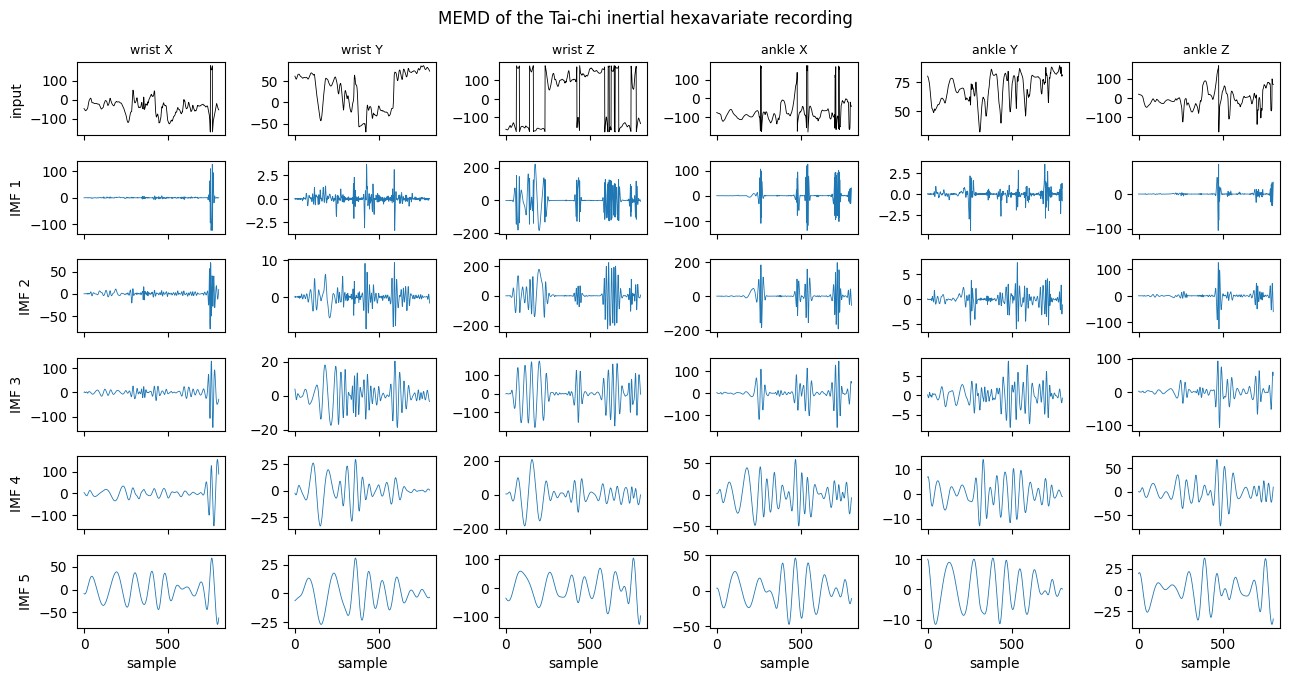

In [9]:
taichi = load_memd_taichi_hex()
tc = taichi["signal"]
tt = taichi["t"]
print("Tai-chi hexavariate:", tc.shape)

tc_imfs = MEMD(n_dir=48, max_iter=150).fit_transform(tc)
print(
    "IMFs",
    tc_imfs.shape,
    "recon max |error|",
    np.max(np.abs(tc_imfs.sum(axis=0).T - tc)),
)

names = ["wrist X", "wrist Y", "wrist Z", "ankle X", "ankle Y", "ankle Z"]
n_show = min(5, tc_imfs.shape[0])
fig, axes = plt.subplots(n_show + 1, 6, figsize=(13, 1.15 * (n_show + 1)), sharex=True)
for c, name in enumerate(names):
    axes[0, c].plot(tt, tc[c], color="k", lw=0.6)
    axes[0, c].set_title(name, fontsize=9)
    if c == 0:
        axes[0, c].set_ylabel("input")
    for k in range(n_show):
        axes[k + 1, c].plot(tt, tc_imfs[k, :, c], lw=0.6)
        if c == 0:
            axes[k + 1, c].set_ylabel(f"IMF {k + 1}")
        if k == n_show - 1:
            axes[k + 1, c].set_xlabel("sample")
fig.suptitle("MEMD of the Tai-chi inertial hexavariate recording")
plt.tight_layout()
plt.show()

## 8. Practical notes

- **Input shape.** Prefer `(n_channels, n_samples)` with `3 ≤ n_channels ≤ 16`.
  A MATLAB-style `(T, C)` array is transposed automatically when `C` is in
  that range and `T` is not.
- **`n_dir`.** Default 64, matching `memd.m`. Larger \(K\) (paper: 512) refines
  the spherical integral at cubic cost in the projection loop.
- **Stopping.** `"stop"` uses Rilling's `(sd, sd2, tol)` vector (default
  `[0.075, 0.75, 0.075]`). `"fix_h"` counts consecutive siftings where the
  numbers of extrema and zero-crossings differ by at most one.
- **Residue.** The last slice along axis 0 is the monotonic / low-frequency
  remainder; include it when reconstructing.
- **Related methods.** Univariate EMD / EEMD / CEEMDAN for one channel;
  **MVMD** for a variational multivariate alternative; **BMEMD** for
  jointly decomposing a stack of images `(C, H, W)`.
